In [1]:
import pandas as pd

# Load all 4 files
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

# Merge train with features and stores
df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Group by date to get weekly total sales
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().resample('W').sum().reset_index()

# Save it
weekly_sales.to_csv("walmart_weekly_sales.csv", index=False)

print("✅ 'walmart_weekly_sales.csv' created successfully.")

# Have an overview of the data
weekly_sales.head()

✅ 'walmart_weekly_sales.csv' created successfully.


,Date,Weekly_Sales
0,2010-02-07,49750740.50
1,2010-02-14,48336677.63
2,2010-02-21,48276993.78
3,2010-02-28,43968571.13
4,2010-03-07,46871470.30


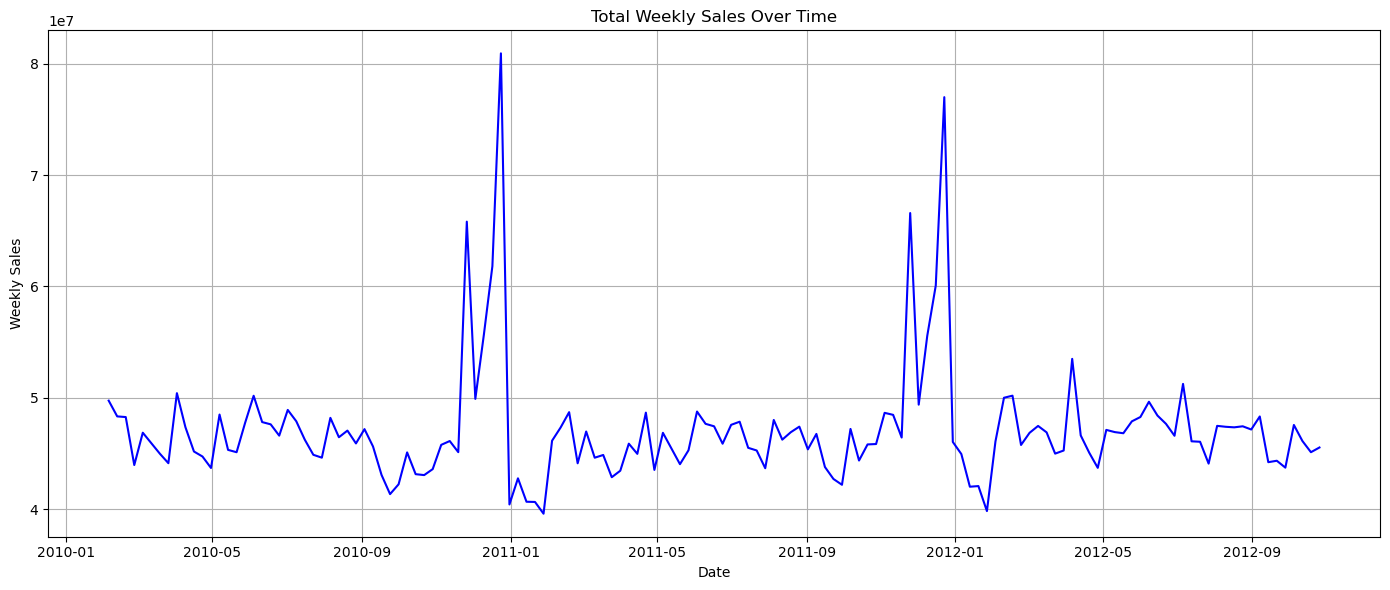

In [2]:
import matplotlib.pyplot as plt

# Create a weekly total sales series
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()

# Plot the time series
plt.figure(figsize=(14,6))
plt.plot(weekly_sales, color='blue')
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

Missing Values:
 MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64


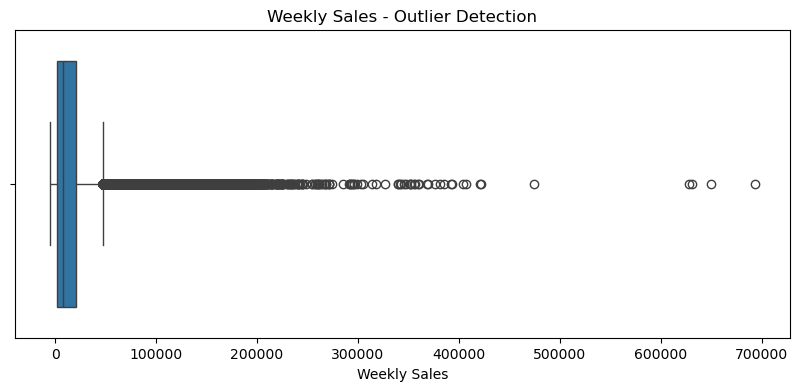

In [3]:
import seaborn as sns

# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Missing Values:\n", missing_values)

# Outlier detection using a boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Weekly_Sales'])
plt.title("Weekly Sales - Outlier Detection")
plt.xlabel("Weekly Sales")
plt.show()

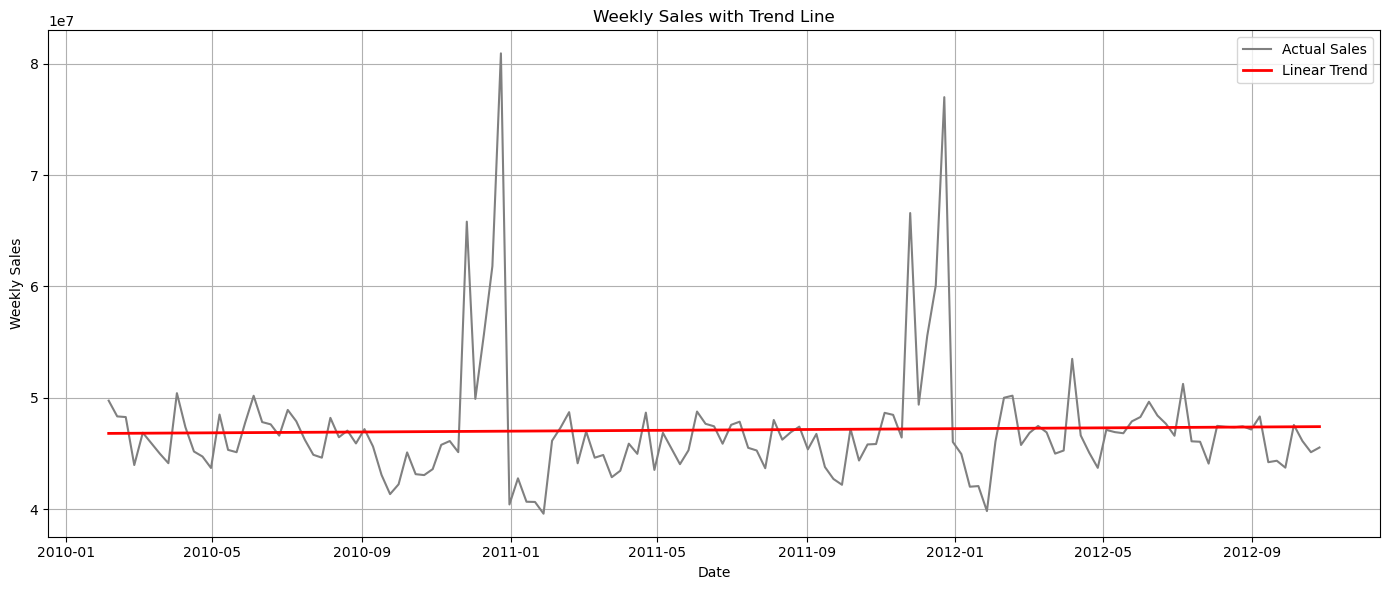

In [4]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
sales_ts = weekly_sales.reset_index()
sales_ts.dropna(inplace=True)
sales_ts['Timestamp'] = sales_ts['Date'].map(pd.Timestamp.toordinal)  # Convert dates to numeric

# Fit linear trend line
X = sales_ts['Timestamp'].values.reshape(-1, 1)
y = sales_ts['Weekly_Sales'].values
model = LinearRegression()
model.fit(X, y)
trend = model.predict(X)

# Plot actual vs trend line
plt.figure(figsize=(14,6))
plt.plot(sales_ts['Date'], sales_ts['Weekly_Sales'], label='Actual Sales', color='gray')
plt.plot(sales_ts['Date'], trend, label='Linear Trend', color='red', linewidth=2)
plt.title("Weekly Sales with Trend Line")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

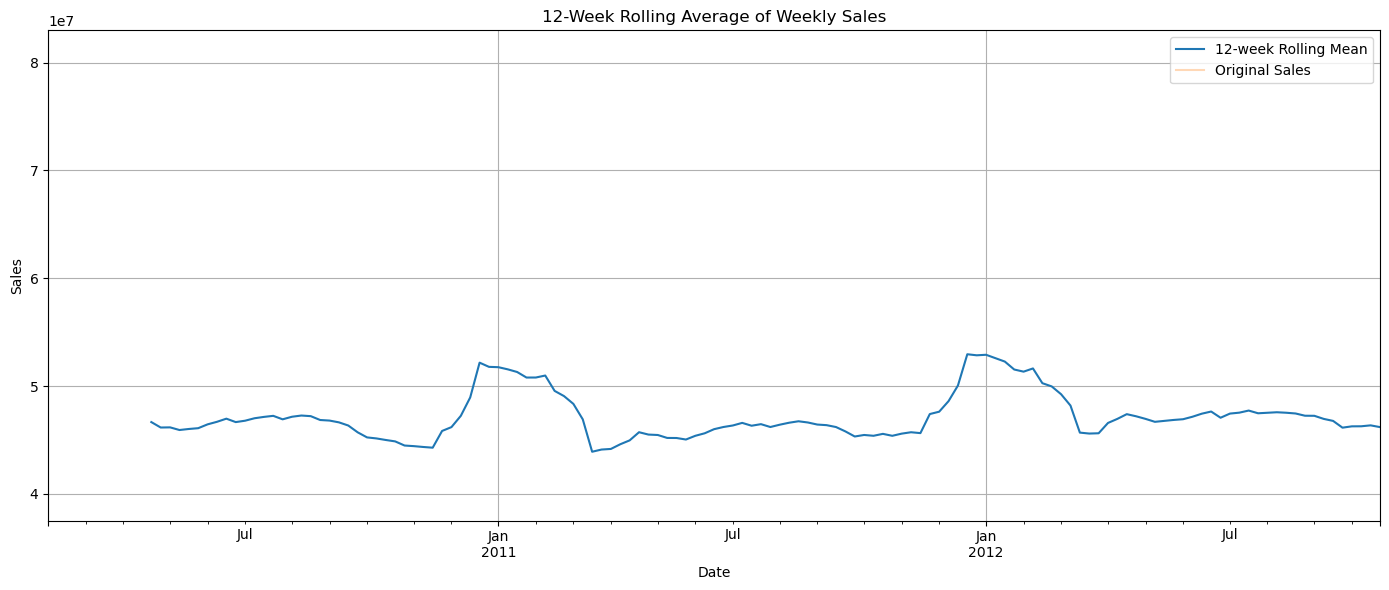

In [5]:
# Plotting 12-week rolling average to visualize sales trend with original values for reference
weekly_sales.rolling(window=12).mean().plot(figsize=(14,6), label='12-week Rolling Mean')
plt.plot(weekly_sales, alpha=0.3, label='Original Sales')
plt.title("12-Week Rolling Average of Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test
result = adfuller(weekly_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

# Interpretation guidance
if result[1] <= 0.05:
    print("\n✅ The data is stationary (p <= 0.05). No differencing needed.")
else:
    print("\n⚠️ The data is NOT stationary (p > 0.05). Consider differencing.")

ADF Statistic: -5.908297957186333
p-value: 2.675979158986027e-07
Critical Value (1%): -3.47864788917503
Critical Value (5%): -2.882721765644168
Critical Value (10%): -2.578065326612056

✅ The data is stationary (p <= 0.05). No differencing needed.


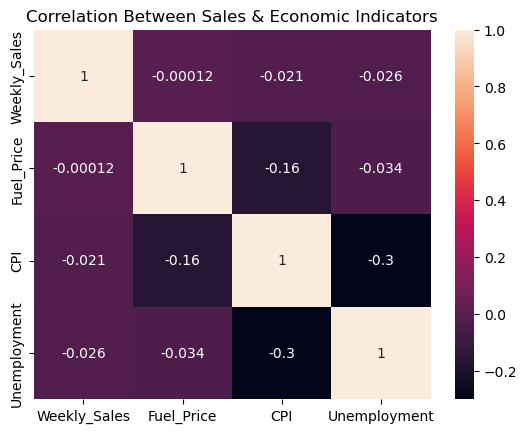

In [7]:
# Heatmap showing correlation between weekly sales and key economic indicators
sns.heatmap(df[['Weekly_Sales', 'Fuel_Price', 'CPI', 'Unemployment']].corr(), annot=True)
plt.title("Correlation Between Sales & Economic Indicators")
plt.show()

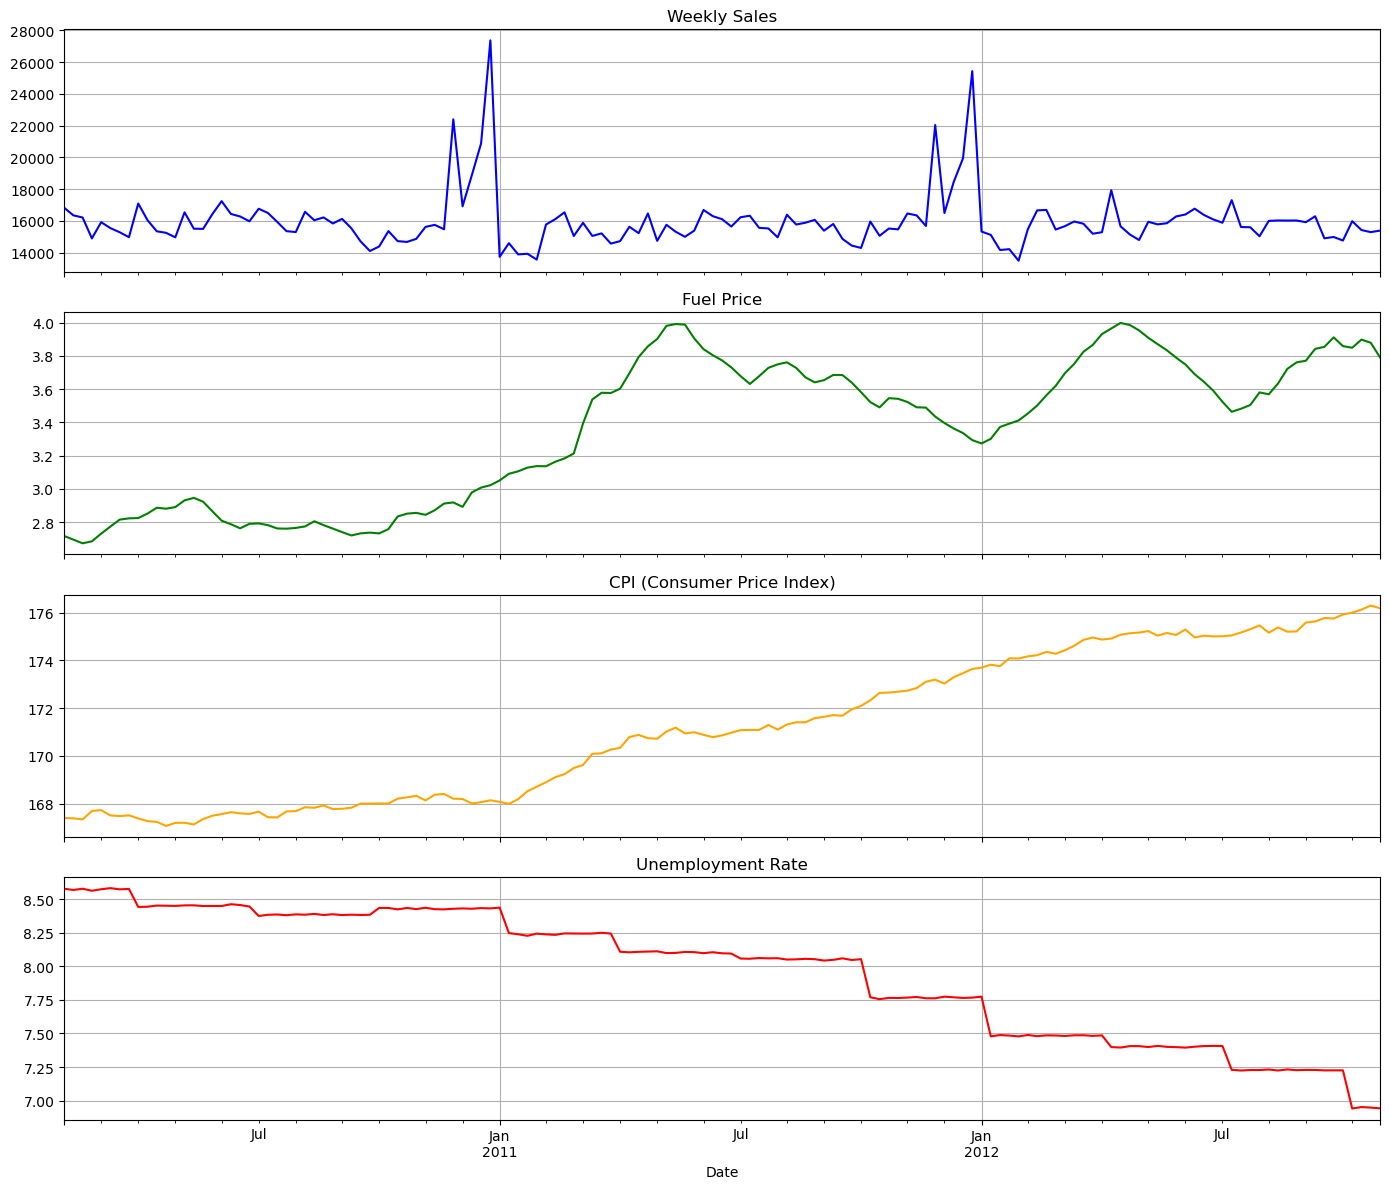

In [8]:
# Resample relevant economic features weekly
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
econ_df = df[['Weekly_Sales', 'Fuel_Price', 'CPI', 'Unemployment']].copy()
econ_df = econ_df.resample('W').mean()

# Plot together for visual comparison
fig, axs = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

econ_df['Weekly_Sales'].plot(ax=axs[0], title='Weekly Sales', color='blue')
econ_df['Fuel_Price'].plot(ax=axs[1], title='Fuel Price', color='green')
econ_df['CPI'].plot(ax=axs[2], title='CPI (Consumer Price Index)', color='orange')
econ_df['Unemployment'].plot(ax=axs[3], title='Unemployment Rate', color='red')

for ax in axs:
    ax.grid(True)

plt.tight_layout()
plt.show()

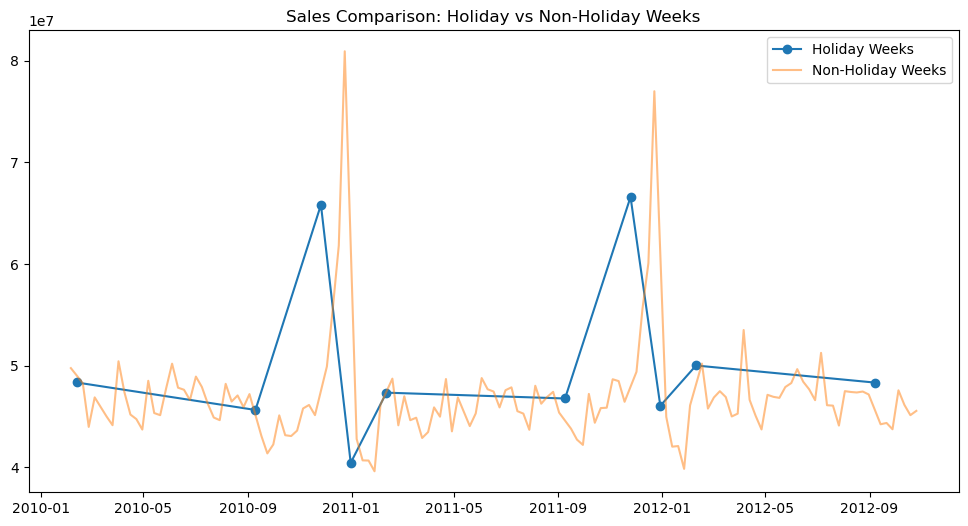

In [9]:
# Comparing total weekly sales during holiday and non-holiday periods to identify seasonal patterns
holiday_sales = df[df['IsHoliday'] == True].groupby('Date')['Weekly_Sales'].sum()
regular_sales = df[df['IsHoliday'] == False].groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12,6))
plt.plot(holiday_sales, label='Holiday Weeks', marker='o')
plt.plot(regular_sales, label='Non-Holiday Weeks', alpha=0.5)
plt.title("Sales Comparison: Holiday vs Non-Holiday Weeks")
plt.legend()
plt.show()

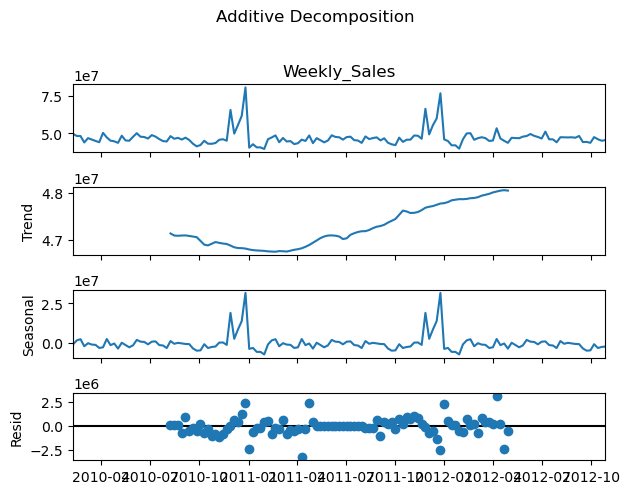

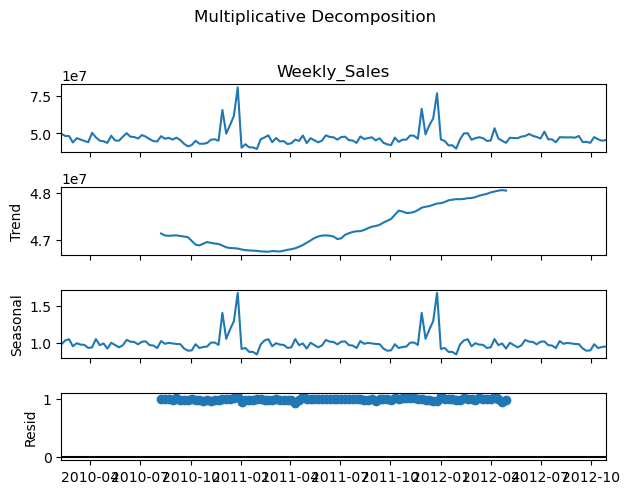

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to ensure uniform weekly intervals
sales_weekly = weekly_sales.resample('W').sum()

# Additive Decomposition
add_decomp = seasonal_decompose(sales_weekly, model='additive')
add_decomp.plot()
plt.suptitle('Additive Decomposition', y=1.02)
plt.tight_layout()
plt.show()

# Multiplicative Decomposition
mult_decomp = seasonal_decompose(sales_weekly, model='multiplicative')
mult_decomp.plot()
plt.suptitle('Multiplicative Decomposition', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Split the time series into training and testing sets
# Using 80% of the data for training
split_index = int(len(sales_weekly) * 0.8)
train_data = sales_weekly[:split_index]
test_data = sales_weekly[split_index:]

# Display lengths
print(f"Training data points: {len(train_data)}")
print(f"Testing data points: {len(test_data)}")

Training data points: 114
Testing data points: 29


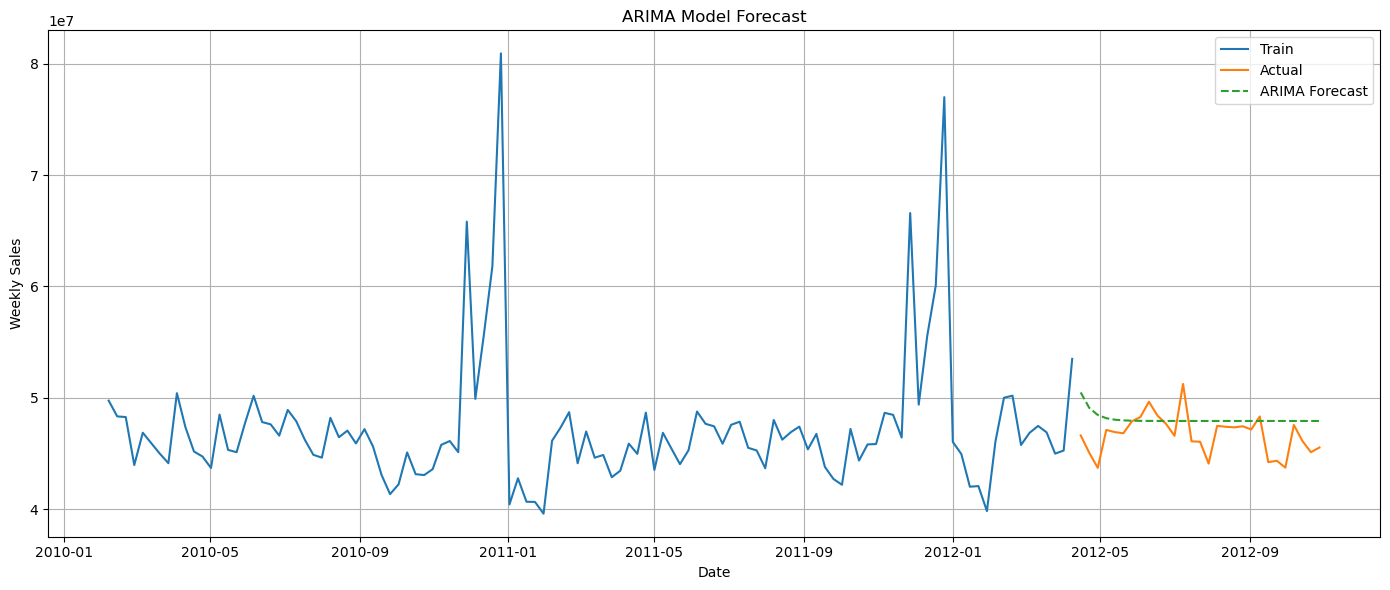

In [12]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model_arima = ARIMA(train_data, order=(1,1,1))
fit_arima = model_arima.fit()

# Forecast
forecast_arima = fit_arima.forecast(steps=len(test_data))

# Plot
plt.figure(figsize=(14,6))
plt.plot(train_data, label='Train')
plt.plot(test_data, label='Actual')
plt.plot(test_data.index, forecast_arima, label='ARIMA Forecast', linestyle='--')
plt.title('ARIMA Model Forecast')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\saluj\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


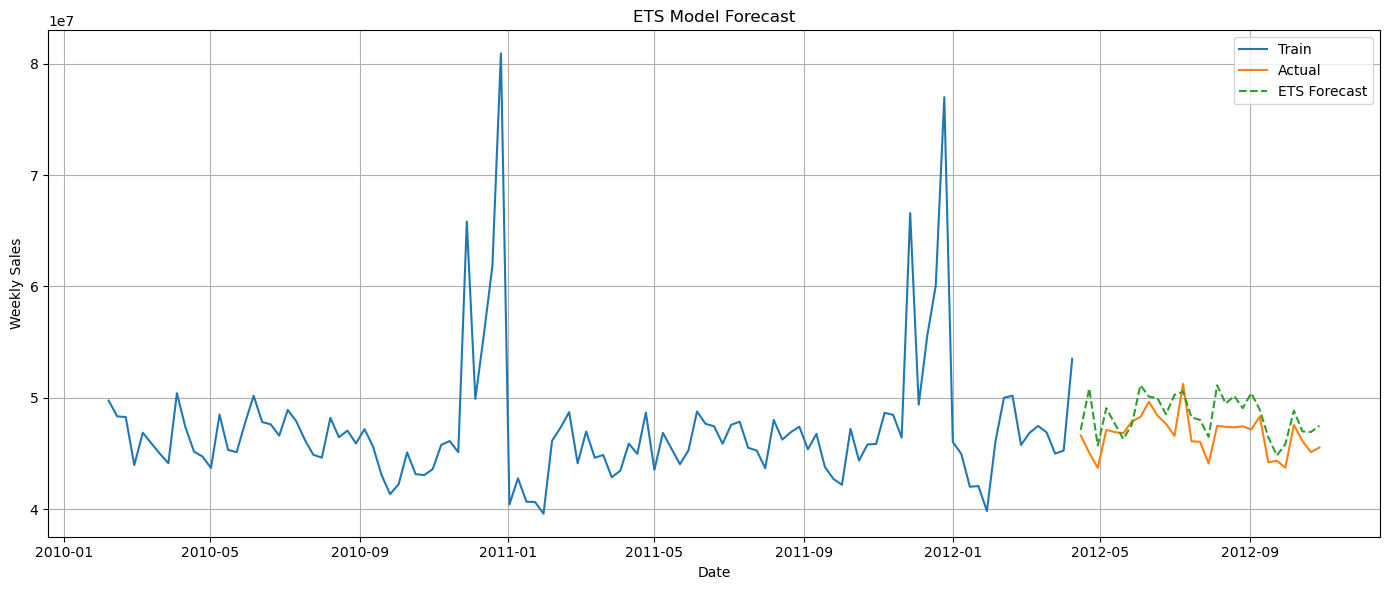

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit ETS model (Additive trend and seasonality, assuming yearly seasonality = 52 weeks)
model_ets = ExponentialSmoothing(
    train_data,
    trend='add',
    seasonal='add',
    seasonal_periods=52
)
fit_ets = model_ets.fit()

# Forecast
forecast_ets = fit_ets.forecast(steps=len(test_data))

# Plot
plt.figure(figsize=(14,6))
plt.plot(train_data, label='Train')
plt.plot(test_data, label='Actual')
plt.plot(test_data.index, forecast_ets, label='ETS Forecast', linestyle='--')
plt.title('ETS Model Forecast')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

16:23:42 - cmdstanpy - INFO - Chain [1] start processing
16:23:42 - cmdstanpy - INFO - Chain [1] done processing


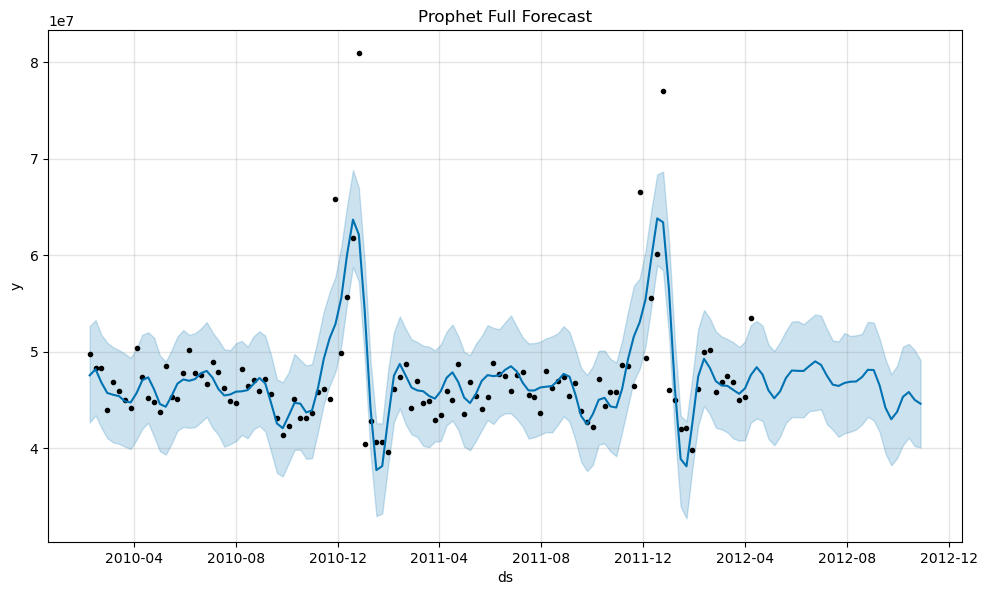

In [14]:
!pip install prophet
from prophet import Prophet

# Prepare the data for Prophet
df_prophet = sales_weekly.reset_index().rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})

# Split for Prophet
split_date = train_data.index[-1]
train_prophet = df_prophet[df_prophet['ds'] <= split_date]
test_prophet = df_prophet[df_prophet['ds'] > split_date]

# Fit the Prophet model
model_prophet = Prophet()
model_prophet.fit(train_prophet)

# Create future dates
future = model_prophet.make_future_dataframe(periods=len(test_prophet), freq='W')
forecast_prophet = model_prophet.predict(future)

# Plot full forecast
model_prophet.plot(forecast_prophet)
plt.title("Prophet Full Forecast")
plt.show()

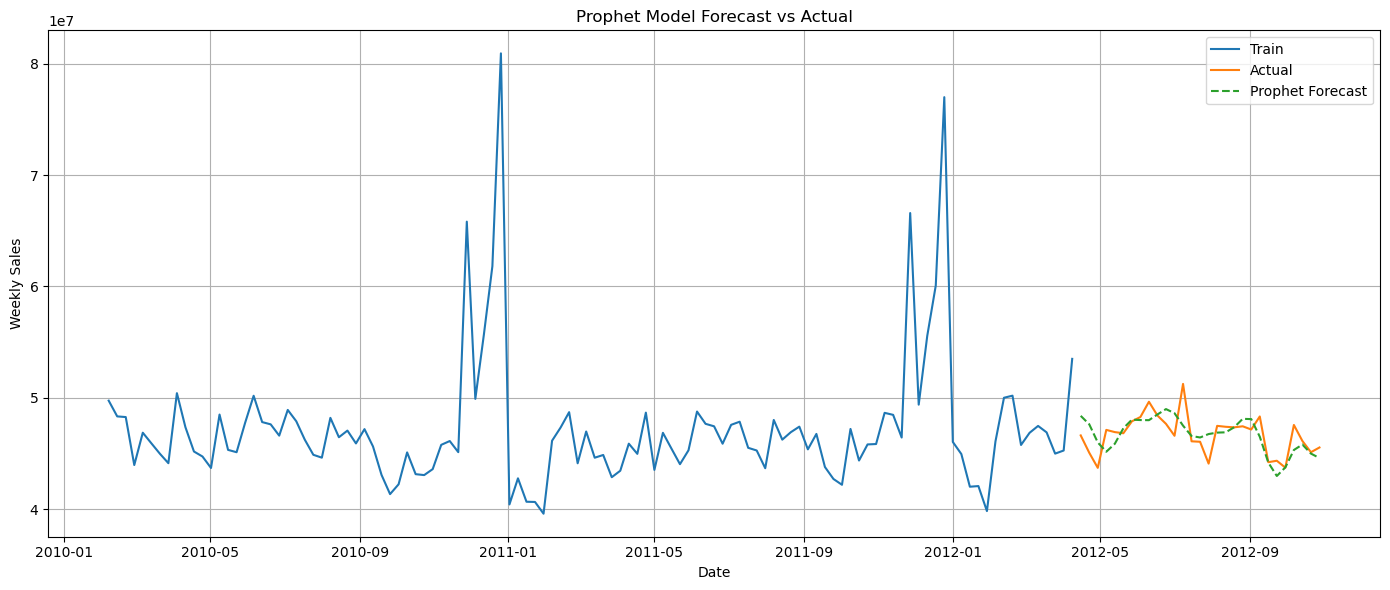

In [15]:
# Align Prophet forecast to test period
forecast_prophet = forecast_prophet.set_index('ds')
prophet_test_forecast = forecast_prophet.loc[test_data.index]['yhat']

# Plot actual vs Prophet forecast
plt.figure(figsize=(14,6))
plt.plot(train_data, label='Train')
plt.plot(test_data, label='Actual')
plt.plot(test_data.index, prophet_test_forecast, label='Prophet Forecast', linestyle='--')
plt.title('Prophet Model Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Convert sales to numpy and reshape for scaling
data = sales_weekly.values.reshape(-1, 1)

# Normalize the data between 0 and 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Set sequence length
lookback = 4

# Create sequences
X, y = [], []
for i in range(lookback, len(scaled_data)):
    X.append(scaled_data[i - lookback:i])
    y.append(scaled_data[i])

X, y = np.array(X), np.array(y)

# Train-test split (same 80/20 ratio)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape input for LSTM [samples, timesteps, features]
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (111, 4, 1)
X_test shape: (28, 4, 1)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Build LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)))
model_lstm.add(Dense(1))  # Output layer

# Compile the model
model_lstm.compile(optimizer='adam', loss='mse')

# Train the model
history = model_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50


C:\Users\saluj\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0568 - val_loss: 0.0130
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0366 - val_loss: 0.0039
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0281 - val_loss: 0.0020
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0186 - val_loss: 0.0023
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0205 - val_loss: 0.0019
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0094 - val_loss: 0.0018
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0233 - val_loss: 0.0020
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0192 - val_loss: 0.0019
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0137 - val_loss: 0.0022
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0255 - val_loss: 0.0020
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0172 - val_loss: 0.0019
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0231 - val_loss: 0.002

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


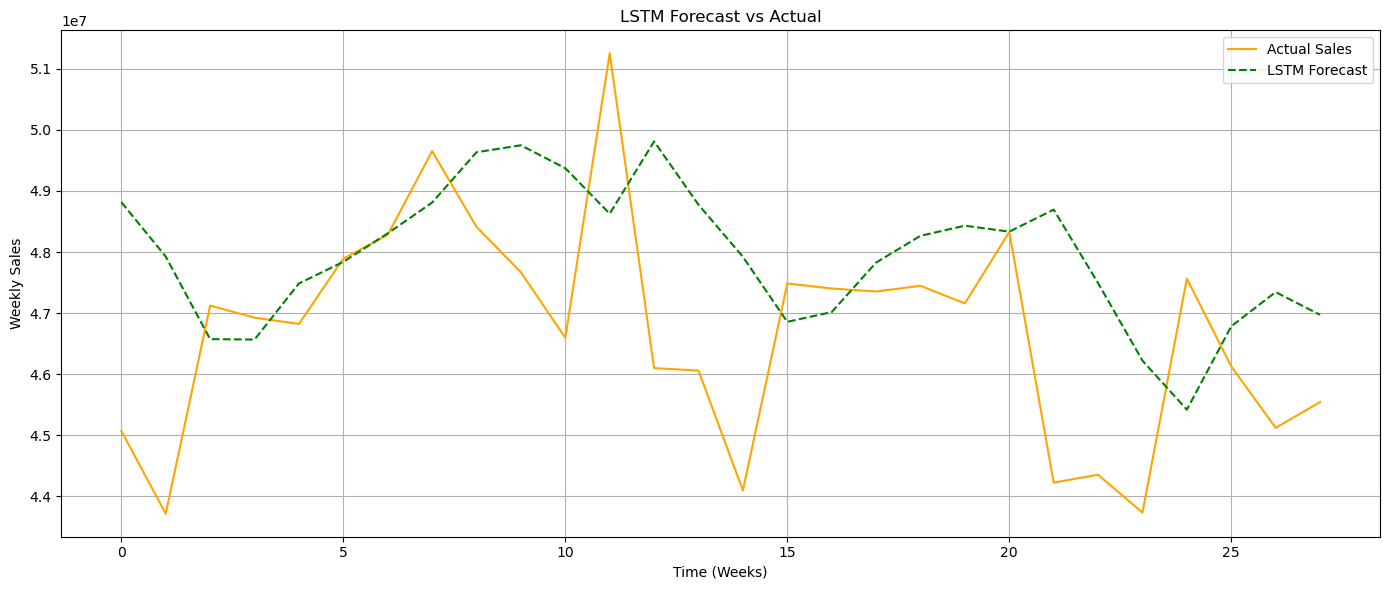

In [18]:
# Predict on test set
y_pred_scaled = model_lstm.predict(X_test)

# Inverse transform predictions and actual values
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test)

# Plot
plt.figure(figsize=(14,6))
plt.plot(y_true, label='Actual Sales', color='orange')
plt.plot(y_pred, label='LSTM Forecast', color='green', linestyle='--')
plt.title("LSTM Forecast vs Actual")
plt.xlabel("Time (Weeks)")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\saluj\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


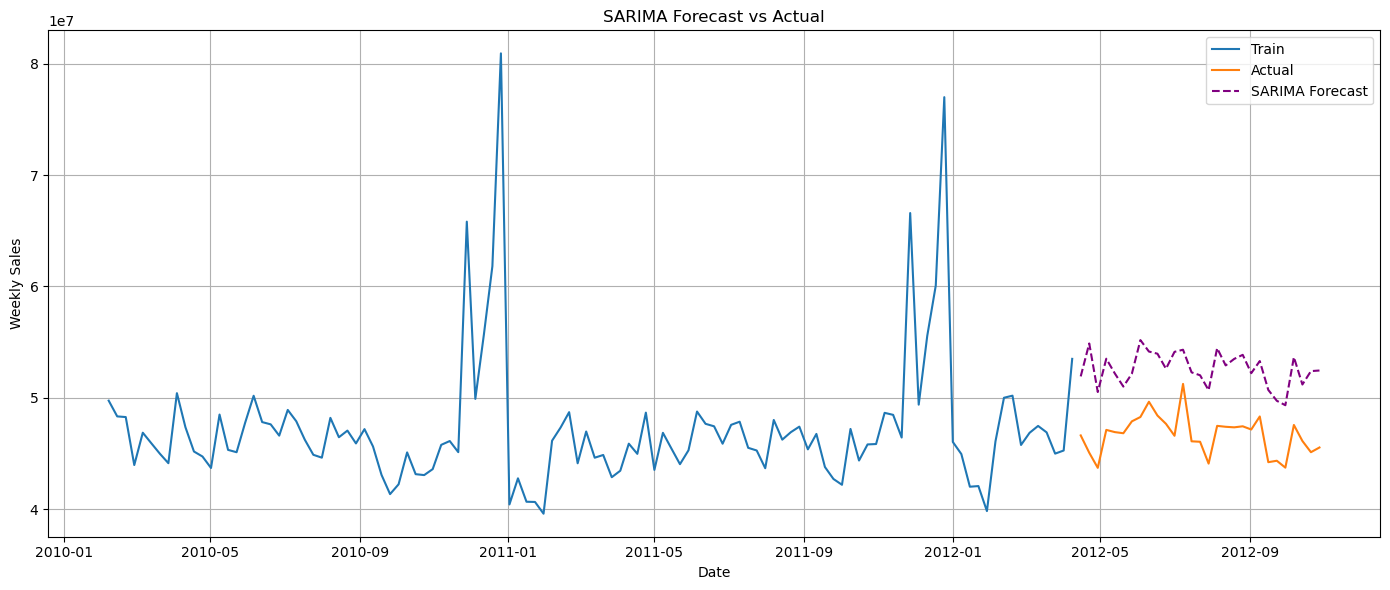

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Define seasonal ARIMA model (SARIMA)
sarima_model = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 52))
sarima_fit = sarima_model.fit(disp=False)

# Forecast
sarima_forecast = sarima_fit.forecast(steps=len(test_data))

# Plot SARIMA forecast vs actual
plt.figure(figsize=(14,6))
plt.plot(train_data, label='Train')
plt.plot(test_data, label='Actual')
plt.plot(test_data.index, sarima_forecast, label='SARIMA Forecast', linestyle='--', color='purple')
plt.title('SARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

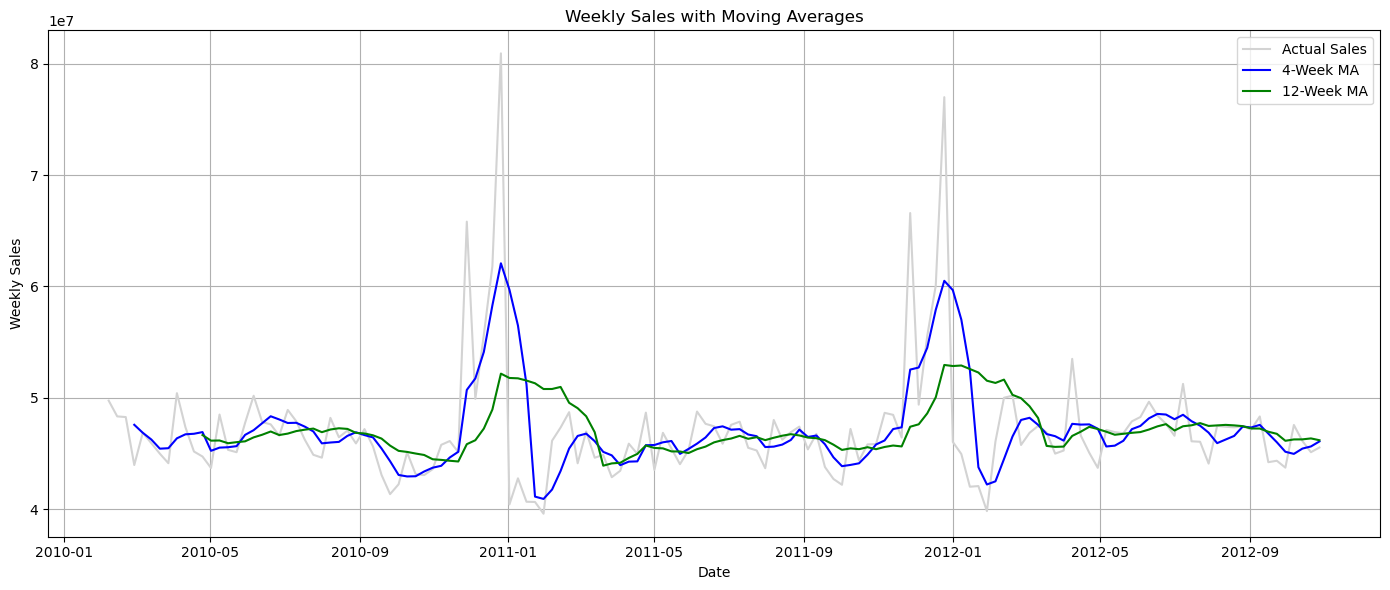

In [20]:
# Plot raw sales vs moving average (4-week and 12-week)
plt.figure(figsize=(14,6))
plt.plot(sales_weekly, label='Actual Sales', color='lightgray')
plt.plot(sales_weekly.rolling(window=4).mean(), label='4-Week MA', color='blue')
plt.plot(sales_weekly.rolling(window=12).mean(), label='12-Week MA', color='green')
plt.title("Weekly Sales with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

,Model,RMSE,MAE,MAPE,MSE
3,Prophet,1.477360e+06,1.118293e+06,2.386805e+00,2.182591e+12
2,ETS,2.201632e+06,1.834588e+06,3.961711e+00,4.847184e+12
0,ARIMA,2.331799e+06,1.826656e+06,3.993105e+00,5.437289e+12
1,SARIMA,6.035320e+06,5.903988e+06,1.271185e+01,3.642509e+13
4,LSTM,4.793705e+07,4.792449e+07,2.982219e+10,2.297960e+15


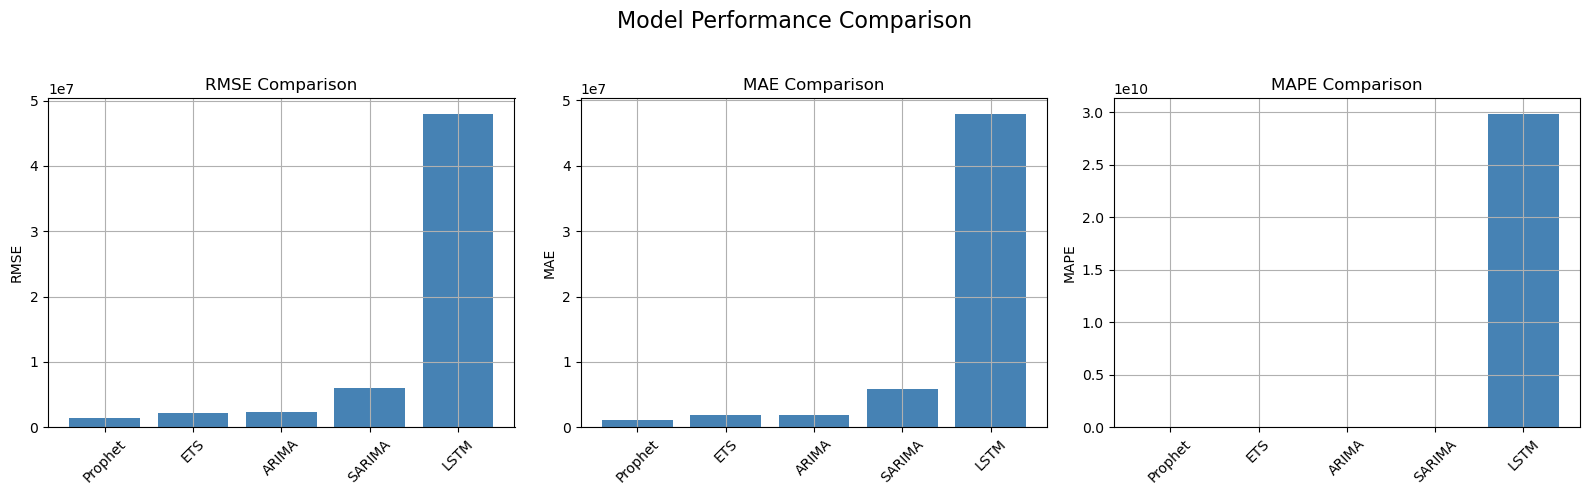

,Model,RMSE,MAE,MAPE,MSE
0,ARIMA,2.331799e+06,1.826656e+06,3.993105e+00,5.437289e+12
1,SARIMA,6.035320e+06,5.903988e+06,1.271185e+01,3.642509e+13
2,ETS,2.201632e+06,1.834588e+06,3.961711e+00,4.847184e+12
3,Prophet,1.477360e+06,1.118293e+06,2.386805e+00,2.182591e+12
4,LSTM,4.793705e+07,4.792449e+07,2.982219e+10,2.297960e+15


In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# --- Define Evaluation Function ---
def evaluate_model(y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mse = mean_squared_error(y_true, y_pred)
    
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "MSE": mse
    }

# --- Store Results ---
results = []

# Evaluate ARIMA
results.append(evaluate_model(test_data, forecast_arima, "ARIMA"))

# Evaluate SARIMA
results.append(evaluate_model(test_data, sarima_forecast, "SARIMA"))

# Evaluate ETS
results.append(evaluate_model(test_data, forecast_ets, "ETS"))

# Evaluate Prophet
results.append(evaluate_model(test_data, prophet_test_forecast, "Prophet"))

# Evaluate LSTM (align lengths if needed)
min_len = min(len(y_test), len(y_pred))
results.append(evaluate_model(y_test[:min_len], y_pred[:min_len], "LSTM"))

# --- Create Results Table ---
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by='RMSE', ascending=True)

# --- Display Results Table ---
display(results_df_sorted)

# --- Plot Comparison Charts ---
metrics_to_plot = ['RMSE', 'MAE', 'MAPE']

plt.figure(figsize=(16, 5))
for i, metric in enumerate(metrics_to_plot):
    plt.subplot(1, 3, i + 1)
    plt.bar(results_df_sorted['Model'], results_df_sorted[metric], color='steelblue')
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.grid(True)

plt.suptitle("Model Performance Comparison", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
results_df


C:\Users\saluj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\saluj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\saluj\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


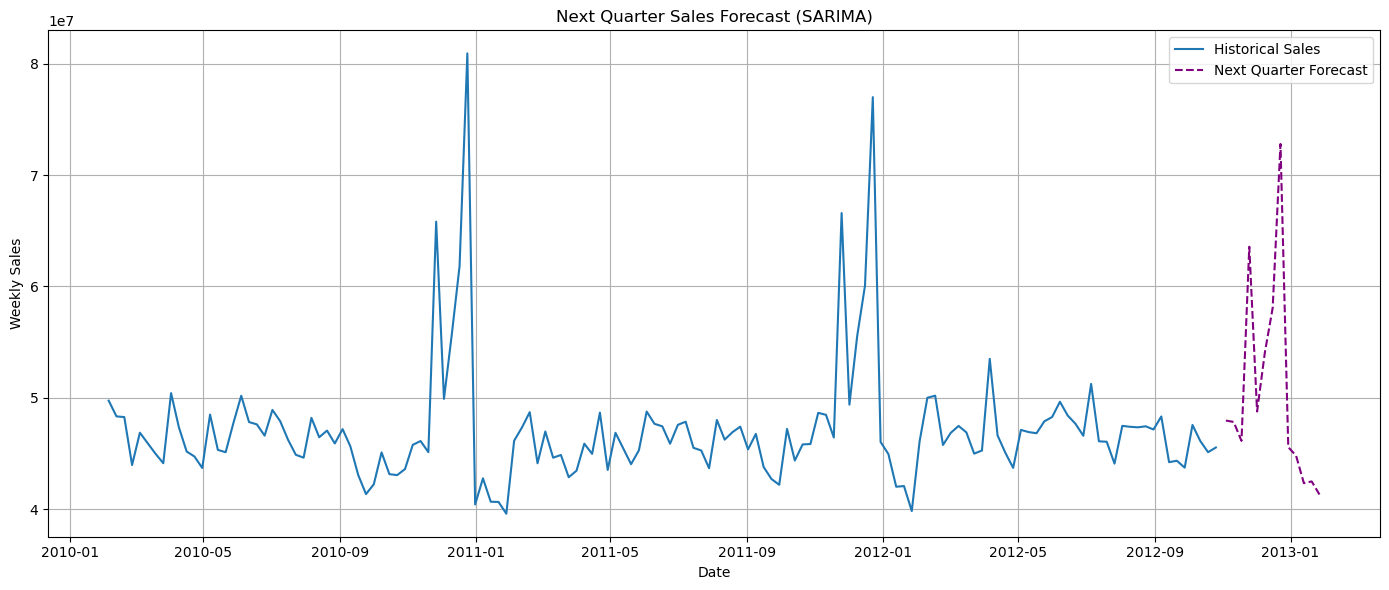

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA
sarima_model = SARIMAX(weekly_sales, order=(1,1,1), seasonal_order=(1,1,1,52))
sarima_fit = sarima_model.fit(disp=False)

# Forecast next 13 weeks
forecast_steps = 13
future_forecast = sarima_fit.forecast(steps=forecast_steps)

# Create dates for next quarter
future_dates = pd.date_range(start=weekly_sales.index[-1] + pd.Timedelta(weeks=1), periods=forecast_steps, freq='W')

# Plot
plt.figure(figsize=(14,6))
plt.plot(weekly_sales, label='Historical Sales')
plt.plot(future_dates, future_forecast, label='Next Quarter Forecast', linestyle='--', color='purple')
plt.title("Next Quarter Sales Forecast (SARIMA)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\saluj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\saluj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\saluj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


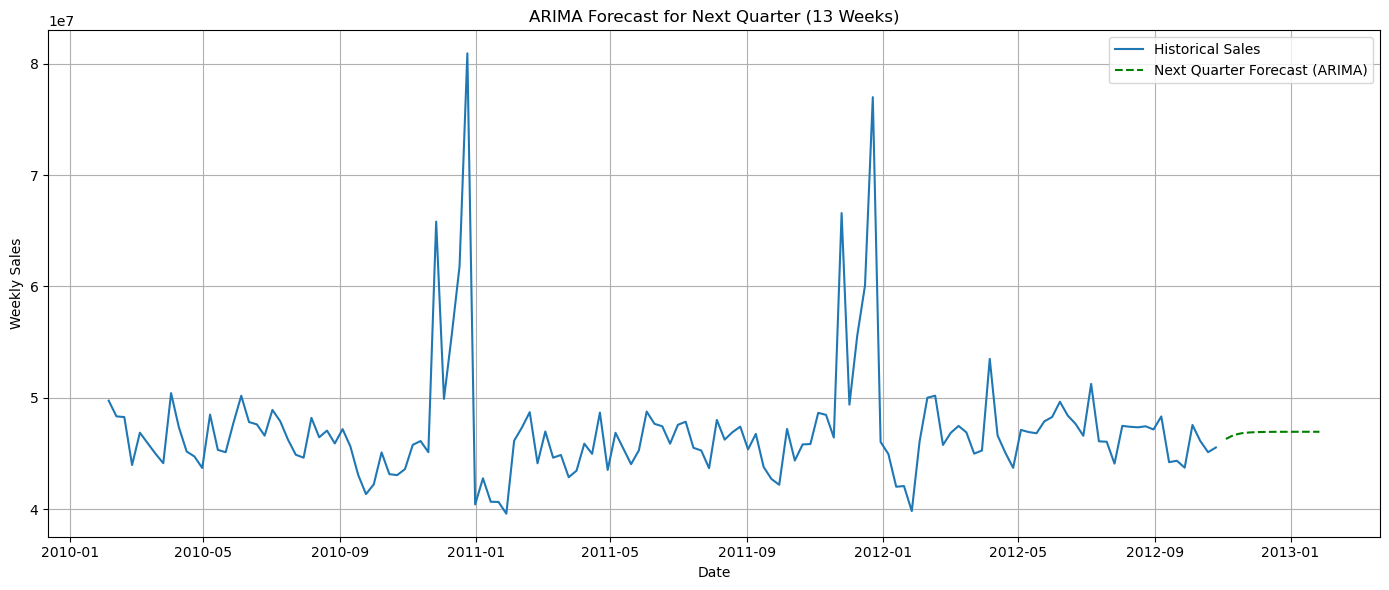

In [23]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pandas as pd

# Fit ARIMA model to full series
arima_model = ARIMA(weekly_sales, order=(1, 1, 1))
arima_fit = arima_model.fit()

# Forecast next 13 weeks (1 quarter)
forecast_steps = 13
arima_forecast = arima_fit.forecast(steps=forecast_steps)

# Create future weekly dates
future_dates = pd.date_range(start=weekly_sales.index[-1] + pd.Timedelta(weeks=1), periods=forecast_steps, freq='W')

# Plot
plt.figure(figsize=(14,6))
plt.plot(weekly_sales, label='Historical Sales')
plt.plot(future_dates, arima_forecast, label='Next Quarter Forecast (ARIMA)', linestyle='--', color='green')
plt.title('ARIMA Forecast for Next Quarter (13 Weeks)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(weekly_sales.values.reshape(-1, 1))

# 2. Create sequences
def create_sequences(data, time_steps=4):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

# 3. Train-test split
split = int(len(scaled_data) * 0.8)
train_scaled = scaled_data[:split]
test_scaled = scaled_data[split:]

X_train, y_train = create_sequences(train_scaled)
X_test, y_test = create_sequences(test_scaled)

# 4. Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# 5. Build and train the LSTM model
model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50


C:\Users\saluj\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0518 - val_loss: 0.0188
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0438 - val_loss: 0.0123
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0401 - val_loss: 0.0069
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0196 - val_loss: 0.0030
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0122 - val_loss: 0.0017
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0209 - val_loss: 0.0024
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0209 - val_loss: 0.0021
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0171 - val_loss: 0.0018
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0189 - val_loss: 0.0017
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0181 - val_loss: 0.0016
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0176 - val_loss: 0.0017
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0196 - val_loss: 0.0017
Epoch 13/50


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


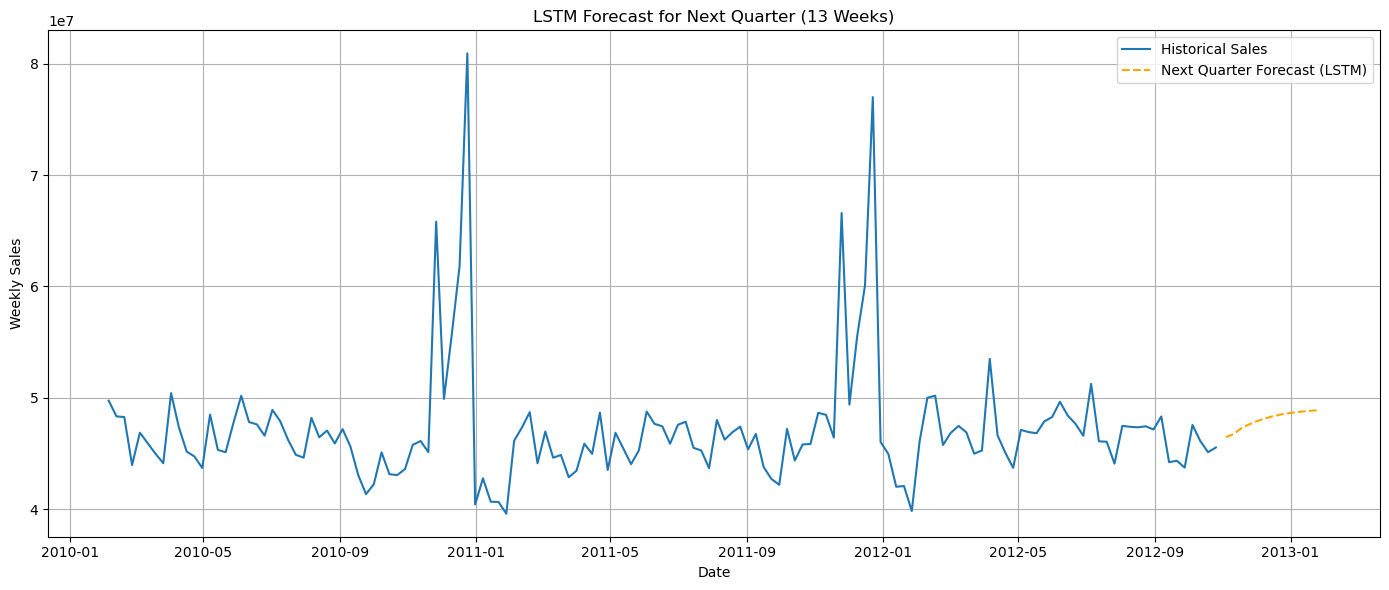

In [25]:
# Forecast next 13 weeks using LSTM
full_data_scaled = np.concatenate((train_scaled, test_scaled))
last_sequence = full_data_scaled[-4:].reshape(1, 4, 1)

future_preds = []

for _ in range(13):
    next_pred = model.predict(last_sequence)[0][0]
    future_preds.append(next_pred)
    last_sequence = np.append(last_sequence[:, 1:, :], [[[next_pred]]], axis=1)

# Inverse transform the predictions
future_preds_inv = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))

# Create future dates
future_dates = pd.date_range(start=weekly_sales.index[-1] + pd.Timedelta(weeks=1), periods=13, freq='W')

# Plot
plt.figure(figsize=(14,6))
plt.plot(weekly_sales, label='Historical Sales')
plt.plot(future_dates, future_preds_inv, label='Next Quarter Forecast (LSTM)', linestyle='--', color='orange')
plt.title('LSTM Forecast for Next Quarter (13 Weeks)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

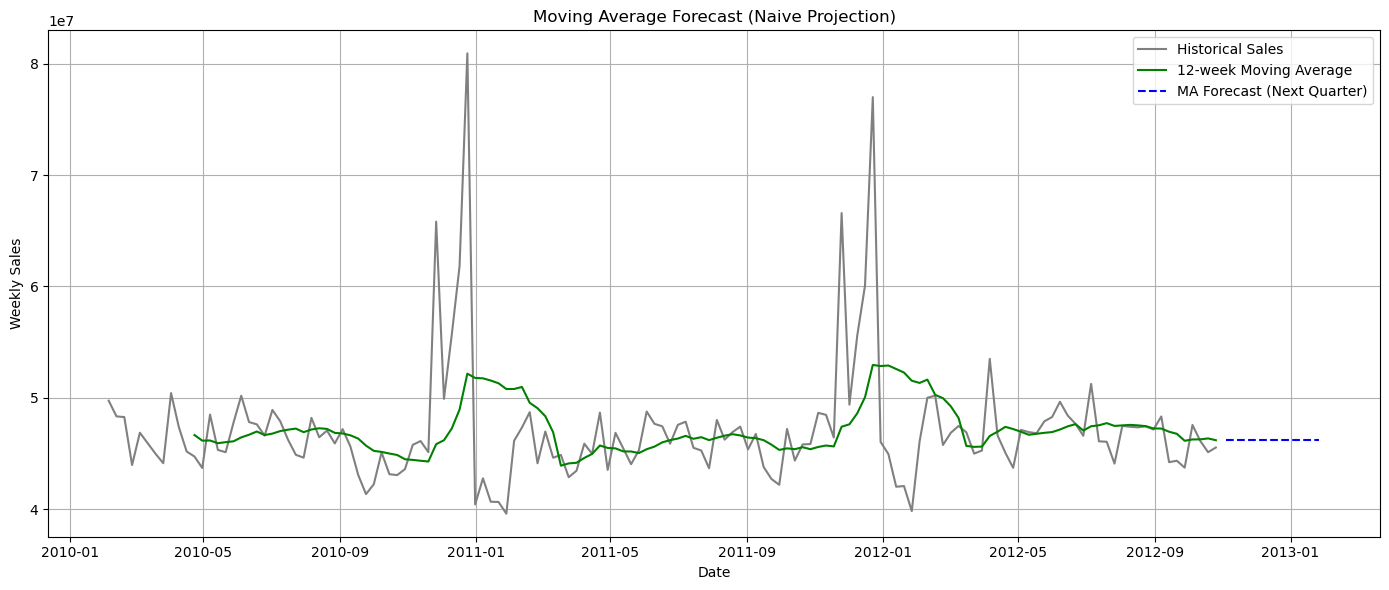

In [26]:
# Calculate 12-week moving average
ma_12 = weekly_sales.rolling(window=12).mean()

# Get the last 12-week average value
last_ma_value = ma_12.dropna().iloc[-1]

# Create future dates
future_dates = pd.date_range(start=weekly_sales.index[-1] + pd.Timedelta(weeks=1), periods=13, freq='W')

# Forecast: flat projection using last MA value
ma_forecast = [last_ma_value] * 13

# Plot
plt.figure(figsize=(14,6))
plt.plot(weekly_sales, label='Historical Sales', color='gray')
plt.plot(ma_12, label='12-week Moving Average', color='green')
plt.plot(future_dates, ma_forecast, label='MA Forecast (Next Quarter)', linestyle='--', color='blue')
plt.title('Moving Average Forecast (Naive Projection)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

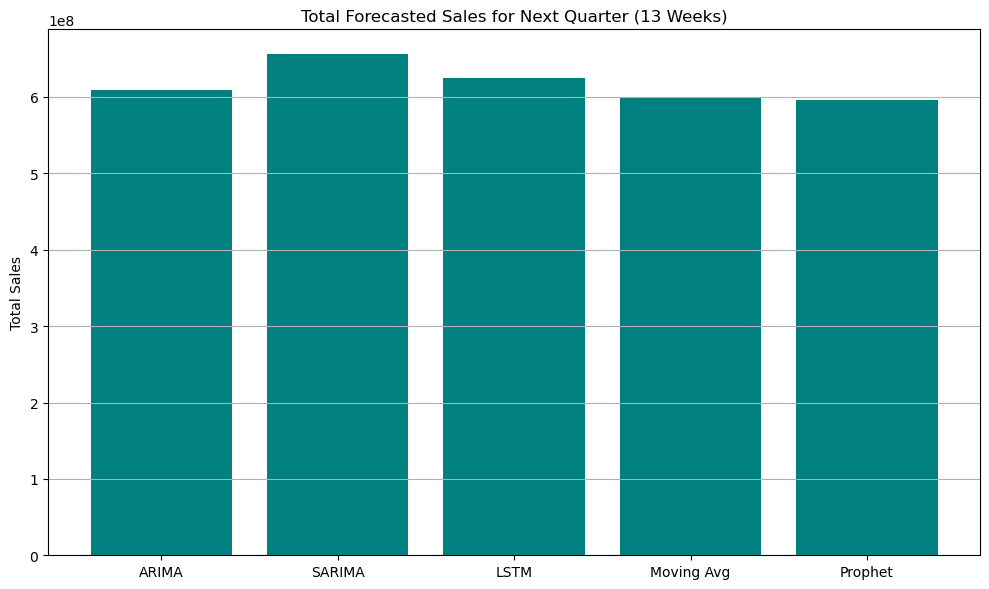

In [27]:
# Prophet: get the last 13 future weeks from yhat
future_prophet_13 = forecast_prophet.tail(13)['yhat']

# Total forecasted sales (sum of next 13 weeks)
summary_data = {
    "Model": ["ARIMA", "SARIMA", "LSTM", "Moving Avg", "Prophet"],
    "Total Forecasted Sales": [
        np.sum(arima_forecast),
        np.sum(future_forecast),
        np.sum(future_preds_inv),
        np.sum(ma_forecast),
        np.sum(future_prophet_13)
    ]
}

# Convert to DataFrame
forecast_summary_df = pd.DataFrame(summary_data)

# Bar Plot
plt.figure(figsize=(10, 6))
plt.bar(forecast_summary_df["Model"], forecast_summary_df["Total Forecasted Sales"], color='teal')
plt.title("Total Forecasted Sales for Next Quarter (13 Weeks)")
plt.ylabel("Total Sales")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [31]:
full_app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

st.set_page_config(page_title="Walmart Sales Forecast", layout="wide")
st.title("🛍️ Walmart Sales Forecasting App")

uploaded_file = st.file_uploader("📁 Upload your CSV file (with 'Date' and 'Weekly_Sales')", type='csv')

if uploaded_file:
    df = pd.read_csv(uploaded_file)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df[['Date', 'Weekly_Sales']]
    df = df.sort_values('Date')
    df.set_index('Date', inplace=True)
    weekly_sales = df['Weekly_Sales'].resample('W').sum()

    st.subheader("📊 Preview of Data")
    st.dataframe(df.head())
    st.write(f"🧾 Total weekly records: {len(weekly_sales)}")

    st.subheader("📈 Moving Averages")
    fig_ma, ax_ma = plt.subplots(figsize=(12, 5))
    ax_ma.plot(weekly_sales, label='Actual Sales', color='gray')
    ax_ma.plot(weekly_sales.rolling(window=4).mean(), label='4-week MA', color='blue')
    ax_ma.plot(weekly_sales.rolling(window=12).mean(), label='12-week MA', color='green')
    ax_ma.set_title("Weekly Sales with Moving Averages")
    ax_ma.legend()
    st.pyplot(fig_ma)

    st.subheader("🧠 Time Series Decomposition")
    model_type = st.radio("Choose decomposition model", ["Additive", "Multiplicative"])
    if len(weekly_sales) >= 52:
        decomp = seasonal_decompose(weekly_sales, model=model_type.lower())
        st.line_chart(decomp.trend)
        st.line_chart(decomp.seasonal)
        st.line_chart(decomp.resid)
    else:
        st.warning("Need at least 1 year (52 weeks) of data for decomposition.")

    st.subheader("📉 Forecasting")
    model_choice = st.selectbox("Select Forecasting Model", ["ARIMA", "SARIMA", "ETS", "Prophet", "LSTM"])

    split_idx = int(len(weekly_sales) * 0.8)
    train = weekly_sales[:split_idx]
    test = weekly_sales[split_idx:]
    forecast = None

    if model_choice == "ARIMA":
        model = ARIMA(train, order=(1, 1, 1))
        fit = model.fit()
        forecast = fit.forecast(steps=len(test))

    elif model_choice == "SARIMA":
        model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 52))
        fit = model.fit(disp=False)
        forecast = fit.forecast(steps=len(test))

    elif model_choice == "ETS":
        if len(train) >= 52:
            model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=52)
            fit = model.fit()
            forecast = fit.forecast(len(test))
        else:
            st.error("ETS requires at least 1 year of training data.")

    elif model_choice == "Prophet":
        df_prophet = weekly_sales.reset_index().rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
        train_prophet = df_prophet[:split_idx]
        model = Prophet()
        model.fit(train_prophet)
        future = model.make_future_dataframe(periods=len(test), freq='W')
        forecast_df = model.predict(future)
        forecast = forecast_df.set_index('ds').loc[test.index]['yhat']
        fig2 = model.plot(forecast_df)
        st.pyplot(fig2)

    elif model_choice == "LSTM":
        scaler = MinMaxScaler()
        scaled_data = scaler.fit_transform(weekly_sales.values.reshape(-1, 1))

        def create_sequences(data, steps=4):
            X, y = [], []
            for i in range(len(data) - steps):
                X.append(data[i:i + steps])
                y.append(data[i + steps])
            return np.array(X), np.array(y)

        X, y = create_sequences(scaled_data)
        split = int(0.8 * len(X))
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]
        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
        X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

        model = Sequential()
        model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)))
        model.add(Dense(1))
        model.compile(optimizer='adam', loss='mse')
        model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)
        y_pred_scaled = model.predict(X_test)
        forecast = scaler.inverse_transform(y_pred_scaled).flatten()
        test = scaler.inverse_transform(y_test).flatten()

    if forecast is not None:
        st.subheader("📊 Forecast vs Actual")
        forecast_index = test.index if model_choice != "LSTM" else weekly_sales[-len(forecast):].index
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(train, label='Train')
        ax.plot(forecast_index, test[:len(forecast)], label='Actual')
        ax.plot(forecast_index, forecast, label=f'{model_choice} Forecast', linestyle='--')
        ax.set_title(f'{model_choice} Forecast vs Actual')
        ax.legend()
        st.pyplot(fig)

        st.subheader("📏 Evaluation Metrics")
        rmse = np.sqrt(mean_squared_error(test[:len(forecast)], forecast))
        mae = mean_absolute_error(test[:len(forecast)], forecast)
        mape = np.mean(np.abs((test[:len(forecast)] - forecast) / test[:len(forecast)])) * 100
        mse = mean_squared_error(test[:len(forecast)], forecast)
        st.metric("RMSE", f"{rmse:,.2f}")
        st.metric("MAE", f"{mae:,.2f}")
        st.metric("MAPE", f"{mape:.2f}%")
        st.metric("MSE", f"{mse:,.2f}")

    st.subheader("🔮 Forecast for Next Quarter (13 Weeks)")
    forecast_steps = 13
    if model_choice == "ARIMA":
        full_model = ARIMA(weekly_sales, order=(1, 1, 1)).fit()
        future_forecast = full_model.forecast(steps=forecast_steps)
    elif model_choice == "SARIMA":
        full_model = SARIMAX(weekly_sales, order=(1, 1, 1), seasonal_order=(1, 1, 1, 52)).fit()
        future_forecast = full_model.forecast(steps=forecast_steps)
    elif model_choice == "ETS":
        full_model = ExponentialSmoothing(weekly_sales, trend='add', seasonal='add', seasonal_periods=52).fit()
        future_forecast = full_model.forecast(forecast_steps)
    elif model_choice == "Prophet":
        df_prophet_full = weekly_sales.reset_index().rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
        full_model = Prophet()
        full_model.fit(df_prophet_full)
        future_dates_df = full_model.make_future_dataframe(periods=forecast_steps, freq='W')
        future_pred = full_model.predict(future_dates_df)
        future_forecast = future_pred.tail(forecast_steps)['yhat'].values
    elif model_choice == "LSTM":
        last_seq = scaled_data[-4:].reshape(1, 4, 1)
        lstm_preds = []
        for _ in range(forecast_steps):
            next_pred = model.predict(last_seq)[0][0]
            lstm_preds.append(next_pred)
            last_seq = np.append(last_seq[:, 1:, :], [[[next_pred]]], axis=1)
        future_forecast = scaler.inverse_transform(np.array(lstm_preds).reshape(-1, 1)).flatten()

    future_dates = pd.date_range(start=weekly_sales.index[-1] + pd.Timedelta(weeks=1), periods=forecast_steps, freq='W')
    fig_next, ax_next = plt.subplots(figsize=(12, 6))
    ax_next.plot(weekly_sales, label='Historical Sales')
    ax_next.plot(future_dates, future_forecast, label='Next Quarter Forecast', linestyle='--')
    ax_next.set_title("Next 13-Week Forecast")
    ax_next.legend()
    st.pyplot(fig_next)
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(full_app_code)

print("✅ app.py saved successfully in your current folder.")

✅ app.py saved successfully in your current folder.
